Successfully read the data using the latin-1 encoding.
Processed data shape: (725, 12)
Method distribution:
method
SA-SCL          145
miniCPM only    145
Markov Chain    145
CGAN            145
TWICE           145
Name: count, dtype: int64

Statistical Summary:
SA-SCL:
  Mean (red line): 0.626
  Median (black line): 0.630
  SD: 0.065
  N = 145

miniCPM only:
  Mean (red line): 0.583
  Median (black line): 0.592
  SD: 0.076
  N = 145

Markov Chain:
  Mean (red line): 0.582
  Median (black line): 0.597
  SD: 0.069
  N = 145

CGAN:
  Mean (red line): 0.566
  Median (black line): 0.580
  SD: 0.059
  N = 145

TWICE:
  Mean (red line): 0.594
  Median (black line): 0.600
  SD: 0.072
  N = 145

Overall statistics:
  Mean: 0.590
  SD: 0.071
  Total samples: 725

The graphic has been saved as:violin_plot_composite_score_with_annotations.png


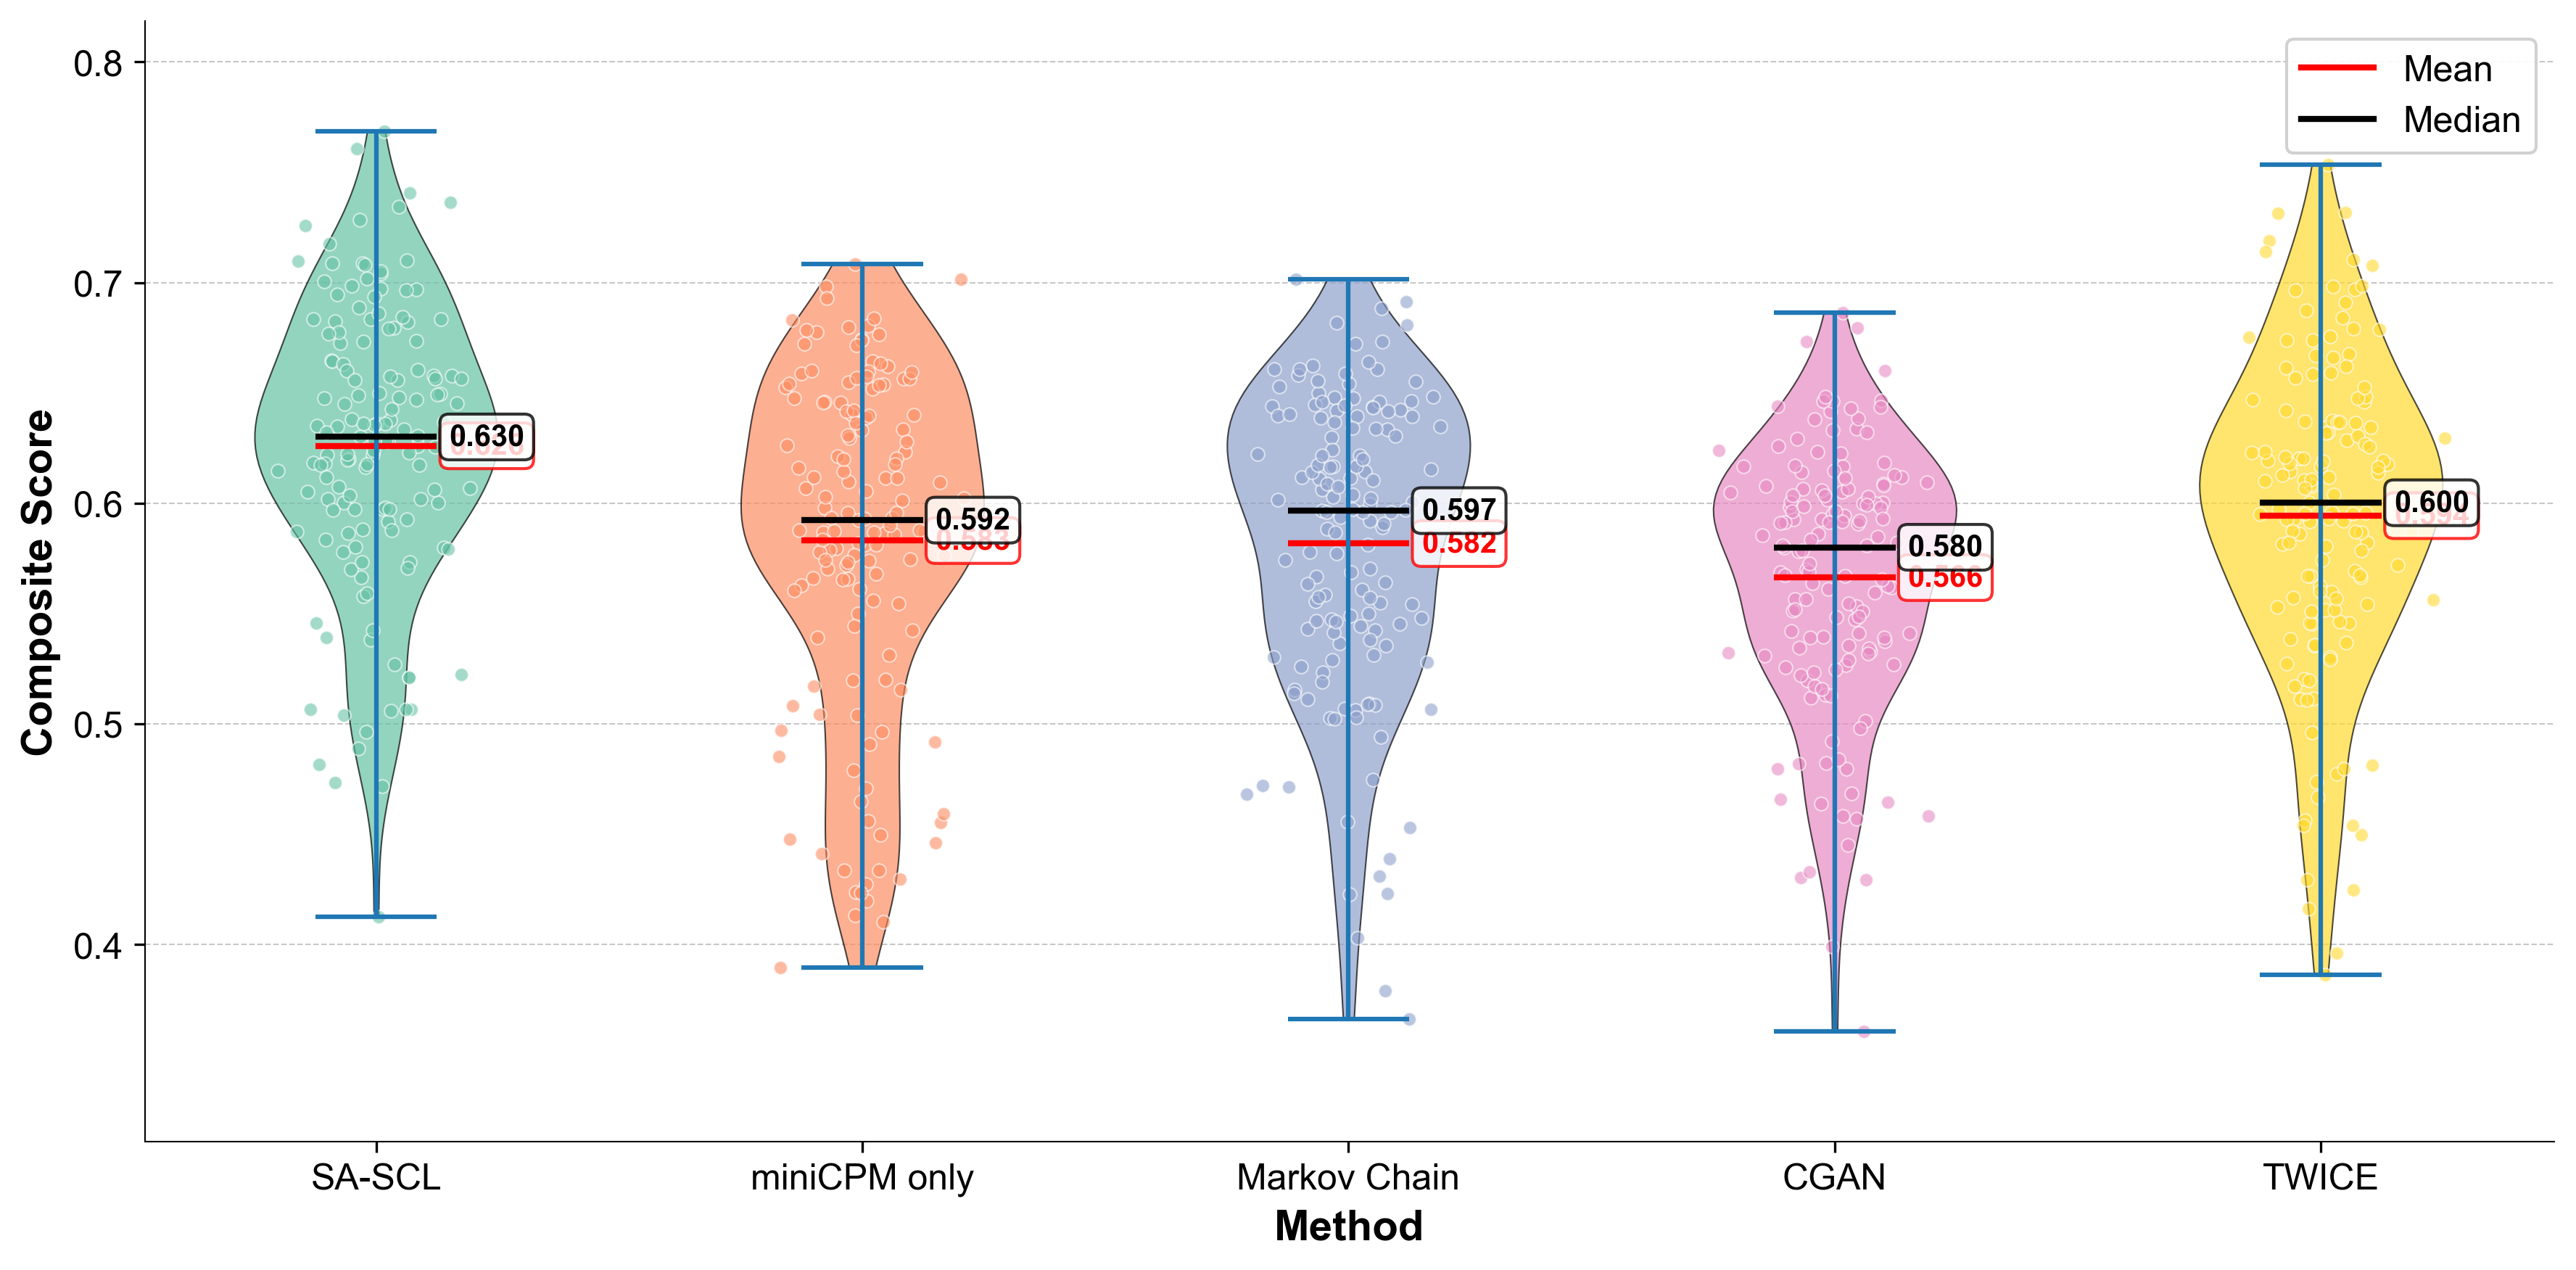


Detailed Statistics for Publication:
Method          Mean (red)   Median (black) SD         N    
--------------------------------------------------------------------------------
SA-SCL          0.626        0.630          0.065      145  
miniCPM only    0.583        0.592          0.076      145  
Markov Chain    0.582        0.597          0.069      145  
CGAN            0.566        0.580          0.059      145  
TWICE           0.594        0.600          0.072      145  


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import numpy as np


plt.rcParams.update({
    'font.size': 12,
    'font.family': 'Arial',
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 16,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1,
})

# Set the color scheme
COLORS = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3', '#ffd92f']  # Five colors

# Read data
try:
    data = pd.read_csv('violin.csv', encoding='utf-8', on_bad_lines='skip')
    print("Successfully read the data using UTF-8 encoding")
except:
    try:
        data = pd.read_csv('violin.csv', encoding='latin-1')
        print("Successfully read the data using the latin-1 encoding.")
    except:
        with open('violin.csv', 'rb') as f:
            content = f.read()
        try:
            decoded = content.decode('utf-8', errors='ignore')
        except:
            decoded = content.decode('latin-1', errors='ignore')
        data = pd.read_csv(io.StringIO(decoded))
        print("Successfully read the data through manual decoding.")

# 检查列名
if 'composite_score' not in data.columns:
    possible_names = ['composite_score', 'composite', 'score', 'composite score']
    for name in possible_names:
        if name in data.columns:
            data = data.rename(columns={name: 'composite_score'})
            break

if 'method' not in data.columns:
    possible_names = ['method', 'Method', 'METHOD', 'model', 'Model', 'approach', 'Approach']
    for name in possible_names:
        if name in data.columns:
            data = data.rename(columns={name: 'method'})
            break

# Clean up the data
if 'composite_score' in data.columns and 'method' in data.columns:
    # Remove missing values
    data = data.dropna(subset=['composite_score'])
    
    # Ensure consistency in the names of the methods
    data['method'] = data['method'].str.strip()
    

    target_methods = ['SA-SCL', 'miniCPM only', 'Markov Chain', 'CGAN', 'TWICE']
    data = data[data['method'].isin(target_methods)]
    

    method_order = ['SA-SCL', 'miniCPM only', 'Markov Chain', 'CGAN', 'TWICE']
    data['method'] = pd.Categorical(data['method'], categories=method_order, ordered=True)
    data = data.sort_values('method')
    
    print(f"Processed data shape: {data.shape}")
    print(f"Method distribution:\n{data['method'].value_counts().sort_index()}")
    
    # Create graphics (adjust the size to fit 5 groups)
    fig, ax = plt.subplots(figsize=(12, 6))
    
    #Create a violin plot
    violin_parts = ax.violinplot(
        [data[data['method'] == method]['composite_score'].values for method in method_order],
        positions=range(len(method_order)),
        showmeans=True,
        showmedians=True,
        showextrema=True
    )
    

    for i, pc in enumerate(violin_parts['bodies']):
        pc.set_facecolor(COLORS[i])
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
        pc.set_linewidth(0.5)
    
    #Set the styles for the mean and median values
    violin_parts['cmeans'].set_color('red')
    violin_parts['cmeans'].set_linewidth(2)
    violin_parts['cmedians'].set_color('black')
    violin_parts['cmedians'].set_linewidth(2)
    
    # Add scatter plot to display data distribution
    for i, method in enumerate(method_order):
        method_data = data[data['method'] == method]['composite_score'].values
        x_pos = np.random.normal(i, 0.08, size=len(method_data))
        ax.scatter(x_pos, method_data, alpha=0.6, color=COLORS[i], s=20, edgecolors='white', linewidth=0.5)
    
    # Set the coordinate axes
    ax.set_xlabel('Method', fontsize=14, fontweight='bold')
    ax.set_ylabel('Composite Score', fontsize=14, fontweight='bold')
    ax.set_xticks(range(len(method_order)))
    ax.set_xticklabels(method_order, rotation=0)
    
    # Set the range of the y-axis
    y_min = max(data['composite_score'].min() - 0.05, 0)
    y_max = min(data['composite_score'].max() + 0.05, 1)
    ax.set_ylim(y_min, y_max)
    
    # Add grid lines
    ax.yaxis.grid(True, linestyle='--', alpha=0.7, linewidth=0.5)
    ax.set_axisbelow(True)
    
    #Remove the top border and the right border
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)
    
    # Add data annotations for each red line (mean) and the black line (median)
    for i, method in enumerate(method_order):
        method_data = data[data['method'] == method]['composite_score']
        mean_val = method_data.mean()
        median_val = method_data.median()
        
        ax.text(i + 0.15, mean_val, f'{mean_val:.3f}', 
                color='red', fontsize=10, fontweight='bold',
                va='center', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='red'))
        
        ax.text(i + 0.15, median_val, f'{median_val:.3f}', 
                color='black', fontsize=10, fontweight='bold',
                va='center', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='black'))
    
    # Add legend to explain the meaning of the lines
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='red', lw=2, label='Mean'),
        Line2D([0], [0], color='black', lw=2, label='Median')
    ]
    ax.legend(handles=legend_elements, loc='upper right', framealpha=0.9)
    
    # Calculate and display statistical information
    print("\n" + "="*60)
    print("Statistical Summary:")
    print("="*60)
    
    stats_table = []
    for i, method in enumerate(method_order):
        method_data = data[data['method'] == method]['composite_score']
        mean_val = method_data.mean()
        std_val = method_data.std()
        median_val = method_data.median()
        n_val = len(method_data)
        
        print(f"{method}:")
        print(f"  Mean (red line): {mean_val:.3f}")
        print(f"  Median (black line): {median_val:.3f}")
        print(f"  SD: {std_val:.3f}")
        print(f"  N = {n_val}")
        print()
        
        stats_table.append([method, f"{mean_val:.3f}", f"{median_val:.3f}", f"{std_val:.3f}", f"{n_val}"])
    
    overall_mean = data['composite_score'].mean()
    overall_std = data['composite_score'].std()
    print(f"Overall statistics:")
    print(f"  Mean: {overall_mean:.3f}")
    print(f"  SD: {overall_std:.3f}")
    print(f"  Total samples: {len(data)}")
    
    plt.tight_layout()
    
    # Save the graphic
    filename = 'violin_plot_composite_score_with_annotations.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"\nThe graphic has been saved as:{filename}")
    
    plt.show()
    
    #Create a detailed statistical table
    print("\n" + "="*80)
    print("Detailed Statistics for Publication:")
    print("="*80)
    print(f"{'Method':<15} {'Mean (red)':<12} {'Median (black)':<14} {'SD':<10} {'N':<5}")
    print("-"*80)
    
    for row in stats_table:
        print(f"{row[0]:<15} {row[1]:<12} {row[2]:<14} {row[3]:<10} {row[4]:<5}")
    
    print("="*80)
    
else:
    print("Error: Unable to find the required column name")
    print("Available column names:", data.columns.tolist())